C:\Users\veron\AppData\Local\Temp\ipykernel_20936\3566094046.py:28: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Using ID column: id_patient


C:\Users\veron\AppData\Local\Temp\ipykernel_20936\3566094046.py:80: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Rows: 24497


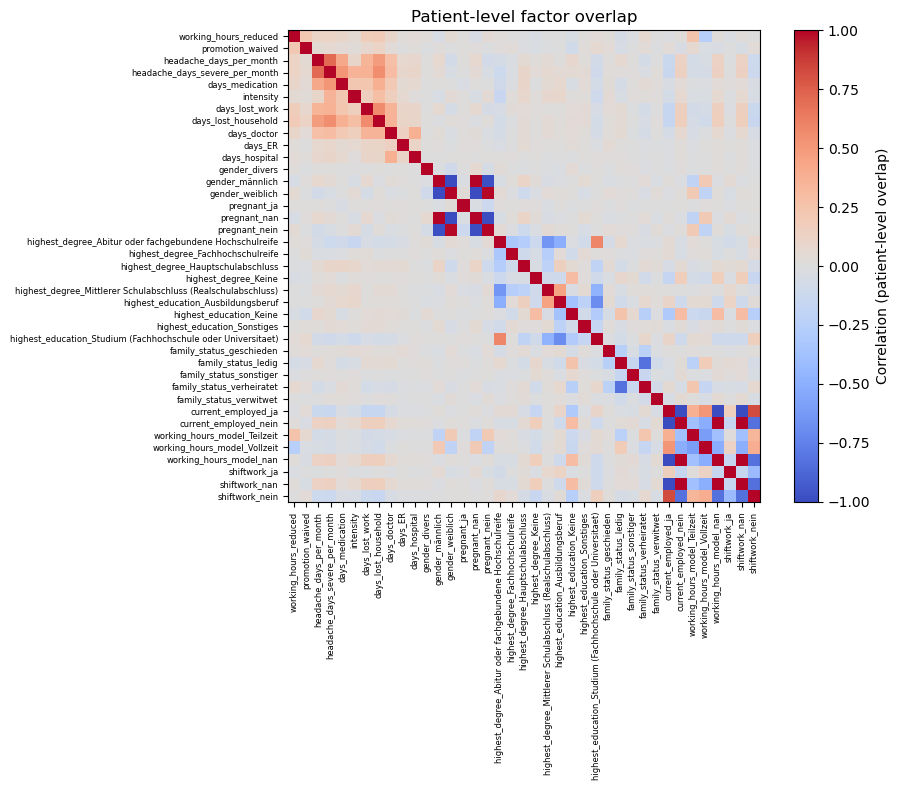


Top overlaps:
current_employed_ja                                      current_employed_nein                                          -1.000000
                                                         working_hours_model_nan                                        -1.000000
current_employed_nein                                    working_hours_model_nan                                         1.000000
                                                         shiftwork_nan                                                   0.997518
working_hours_model_nan                                  shiftwork_nan                                                   0.997518
current_employed_ja                                      shiftwork_nan                                                  -0.997518
gender_weiblich                                          pregnant_nan                                                   -0.997447
gender_männlich                                          pregnant_nan      

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

factor_prefixes = [
    "gender","pregnant",
    "highest_degree","highest_education","family_status",
    "current_employed","working_hours_model","shiftwork",
    "working_hours_reduced","promotion_waived",
    "headache_days_per_month","headache_days_severe_per_month",
    "days_medication","intensity","days_lost_work",
    "days_lost_household","days_doctor","days_ER","days_hospital"
]

# =========================================================
# LOAD DATA
# =========================================================

df = pd.concat(
    [pd.read_csv(f, sep=";", quotechar='"') for f in csv_files],
    ignore_index=True
)

# clean column names
df.columns = (
    df.columns
    .str.replace('"', '', regex=False)
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# robust ID detection
id_candidates = [c for c in df.columns if "id" in c.lower()]
if not id_candidates:
    raise ValueError("No ID column found")
ID_COL = id_candidates[0]

print("Using ID column:", ID_COL)

# =========================================================
# HELPERS
# =========================================================

def collapse_k_columns(df, prefixes):
    out = {}

    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue

        block = df[cols]

        sample = block.stack().dropna()
        numeric_ratio = pd.to_numeric(sample, errors="coerce").notna().mean()

        if numeric_ratio > 0.7:
            num_block = block.apply(pd.to_numeric, errors="coerce")
            out[p] = num_block.mean(axis=1)
        else:
            out[p] = block.bfill(axis=1).iloc[:, 0].astype(str)

    return pd.DataFrame(out)

# =========================================================
# LOAD + COLLAPSE ALL FILES
# =========================================================

frames = []

for file in csv_files:
    d = pd.read_csv(file, sep=";", quotechar='"')

    d.columns = (
        d.columns
        .str.replace('"', '', regex=False)
        .str.replace('\ufeff', '', regex=False)
        .str.strip()
    )

    collapsed = collapse_k_columns(d, factor_prefixes)

    if ID_COL in d.columns:
        collapsed[ID_COL] = d[ID_COL].values
    else:
        continue

    frames.append(collapsed)

data = pd.concat(frames, ignore_index=True)

print("Rows:", len(data))

# =========================================================
# COLLAPSE TO PATIENT LEVEL
# =========================================================

patient = data.groupby(ID_COL).first().reset_index()

# =========================================================
# ONE-HOT ENCODE CATEGORICAL COLUMNS (NaN SAFE)
# =========================================================

numeric_cols = []
cat_dfs = []

for col in patient.columns:
    if col == ID_COL:
        continue

    series = patient[col]

    # drop real NaNs early for categorical handling
    series_clean = series.dropna()

    numeric = pd.to_numeric(series_clean, errors="coerce")
    numeric_ratio = numeric.notna().mean() if len(numeric) > 0 else 0

    if numeric_ratio > 0.7:
        patient[col] = pd.to_numeric(series, errors="coerce")
        numeric_cols.append(col)

    else:
        # categorical → one-hot (NaN excluded)
        dummies = pd.get_dummies(series.astype("object"), prefix=col, dummy_na=False)
        cat_dfs.append(dummies)

# combine
X = pd.concat([patient[numeric_cols]] + cat_dfs, axis=1)

# =========================================================
# STRICT NaN REMOVAL BEFORE CORRELATION
# =========================================================

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=0, how="any")   # remove patients with ANY missing value
X = X.dropna(axis=1, how="any")   # remove features with ANY missing value

# =========================================================
# CORRELATION MATRIX
# =========================================================

corr = X.corr()

# =========================================================
# PLOT HEATMAP
# =========================================================

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation (patient-level overlap)")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)

plt.title("Patient-level factor overlap")

plt.tight_layout()
plt.show()

# =========================================================
# OPTIONAL: TOP CORRELATIONS
# =========================================================

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

print("\nTop overlaps:")
print(corr_pairs.head(20))

C:\Users\veron\AppData\Local\Temp\ipykernel_19468\96961815.py:60: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,1204

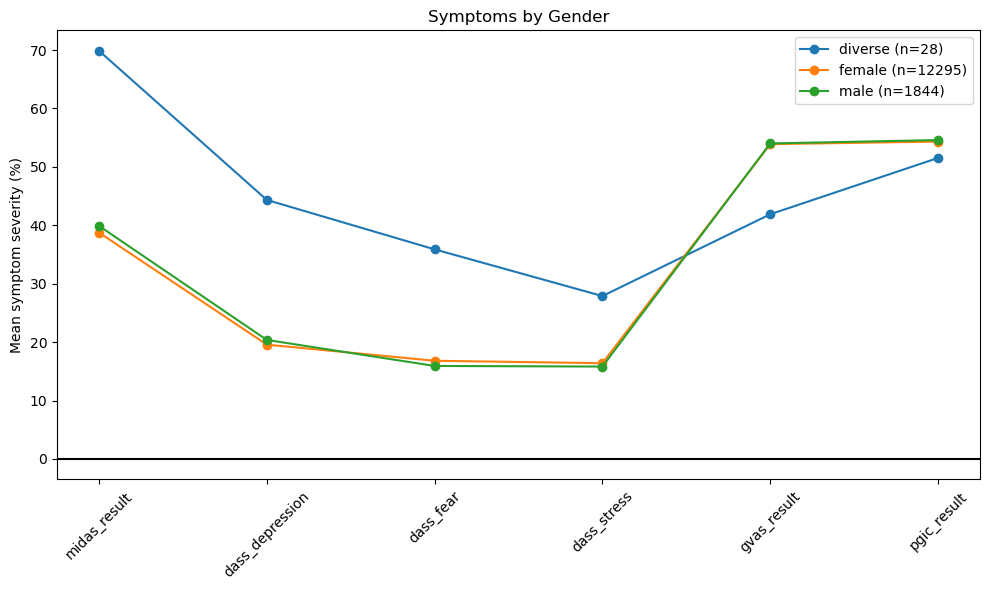

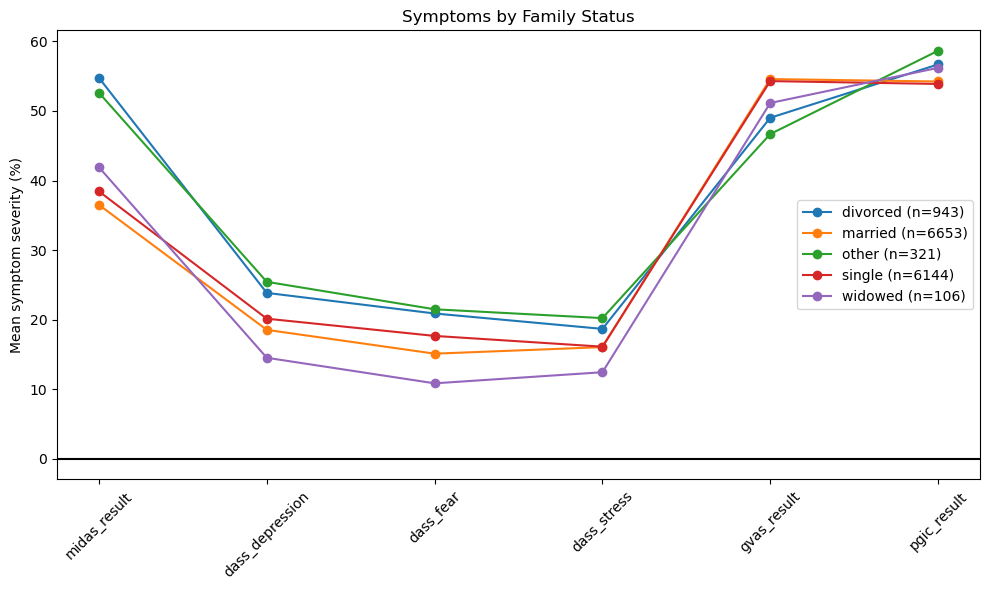

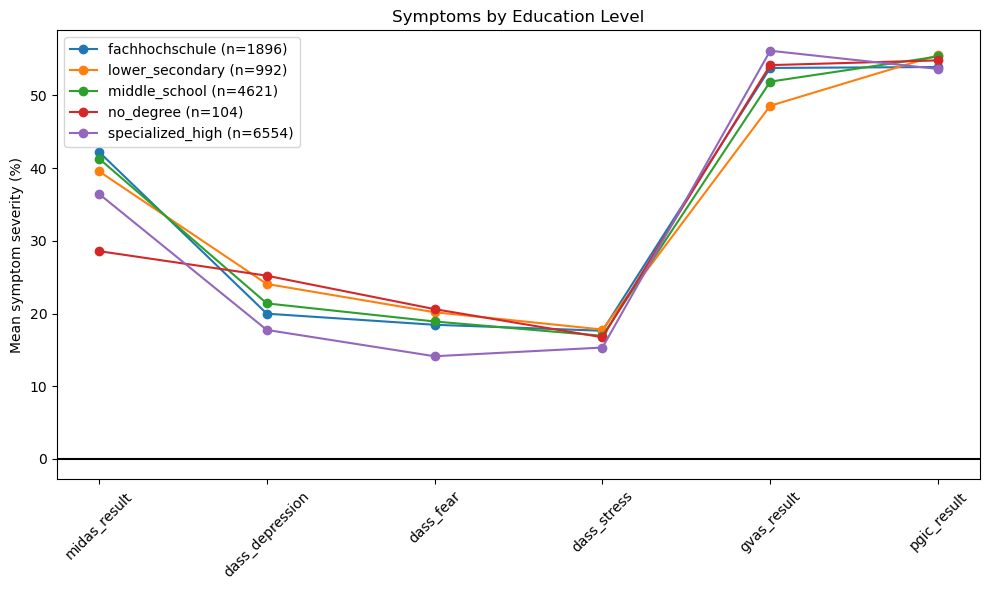

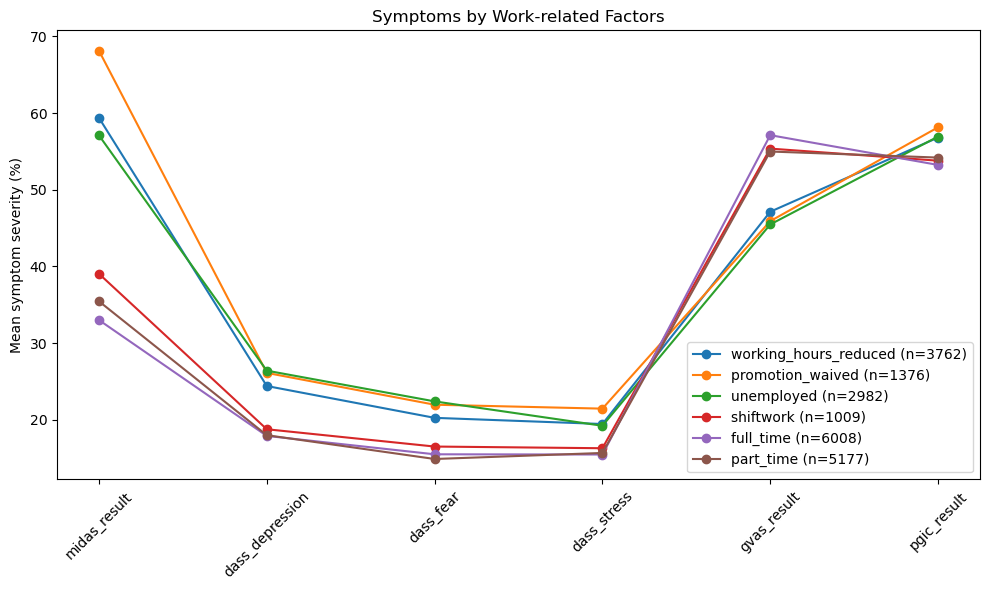

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

score_bases = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "gvas_result",
    "pgic_result"
]

score_ranges = {
    "pgic_result": 7,
    "dass_depression": 24,
    "dass_fear": 21,
    "dass_stress": 42,
    "gvas_result": 100,
    "midas_result": 90
}

# =========================================================
# HELPERS (unchanged)
# =========================================================

def first_nonempty(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        return None
    return df[cols].bfill(axis=1).iloc[:, 0]

def norm(s):
    return s.astype(str).str.lower().str.strip()

K_VALUES = ["k", "ka", "k.a.", "ka.", "keine angabe", "n/a", "na", ""]

def clean_numeric(df):
    return (
        df.replace(K_VALUES, np.nan)
          .apply(pd.to_numeric, errors="coerce")
    )

# =========================================================
# BUILD DATASET (unchanged core logic)
# =========================================================

frames = []

for file in csv_files:

    df = pd.read_csv(file, sep=";")

    df.columns = (
        df.columns.str.replace('"', '', regex=False)
        .str.replace('\ufeff', '', regex=False)
        .str.strip()
    )

    out = {}

    # ---------------- SCORES ----------------
    for base in score_bases:
        cols = [c for c in df.columns if c.startswith(base)]
        if cols:
            score_df = clean_numeric(df[cols])
            out[base] = score_df.mean(axis=1, skipna=True)

    # ---------------- DEMOGRAPHICS ----------------
    g = first_nonempty(df, "gender")
    if g is not None:
        g = norm(g)
        out["gender"] = np.select(
            [
                g.str.contains("männlich|male"),
                g.str.contains("weiblich|female"),
                g.str.contains("divers|other")
            ],
            ["male", "female", "diverse"],
            default="unknown"
        )

    f = first_nonempty(df, "family_status")
    if f is not None:
        f = norm(f)
        out["family_status"] = np.select(
            [
                f.str.contains("verheiratet"),
                f.str.contains("ledig"),
                f.str.contains("geschieden"),
                f.str.contains("verwitwet"),
                f.str.contains("sonst")
            ],
            ["married", "single", "divorced", "widowed", "other"],
            default="unknown"
        )

    e = first_nonempty(df, "highest_degree")
    if e is not None:
        e = norm(e)
        out["education"] = np.select(
            [
                e.str.contains("keine"),
                e.str.contains("haupt"),
                e.str.contains("mittler"),
                e.str.contains("fachhoch"),
                e.str.contains("fachgeb"),
                e.str.contains("abitur")
            ],
            [
                "no_degree",
                "lower_secondary",
                "middle_school",
                "fachhochschule",
                "specialized_high",
                "abitur"
            ],
            default="other"
        )

    # ---------------- WORK ----------------
    def bin_yes_no(series):
        s = norm(series)
        return s.str.contains("ja|yes|true|1").astype(int)

    whr = first_nonempty(df, "working_hours_reduced")
    if whr is not None:
        out["working_hours_reduced"] = bin_yes_no(whr)

    pw = first_nonempty(df, "promotion_waived")
    if pw is not None:
        out["promotion_waived"] = bin_yes_no(pw)

    ce = first_nonempty(df, "current_employed")
    if ce is not None:
        out["unemployed"] = norm(ce).str.contains("nein|no|0").astype(int)

    shift = first_nonempty(df, "shiftwork")
    if shift is not None:
        out["shiftwork"] = bin_yes_no(shift)

    whm = first_nonempty(df, "working_hours_model")
    if whm is not None:
        w = norm(whm)
        out["full_time"] = w.str.contains("vollzeit").astype(int)
        out["part_time"] = w.str.contains("teilzeit").astype(int)

    frames.append(pd.DataFrame(out))

data = pd.concat(frames, ignore_index=True)
data = data.dropna(subset=score_bases)

# scale
for b in score_bases:
    data[b] = (data[b] / score_ranges[b]) * 100

# =========================================================
# 🔥 UPDATED PLOT FUNCTION (ONLY CHANGE HERE)
# =========================================================

def plot_group(col, title):

    if col not in data.columns:
        return

    plt.figure(figsize=(10, 6))

    for g in sorted(data[col].dropna().unique()):
        sub = data[data[col] == g]

        means = [sub[b].mean() for b in score_bases]

        # 🔥 NEW: sample size (N)
        n = len(sub)

        plt.plot(
            score_bases,
            means,
            marker="o",
            label=f"{g} (n={n})"
        )

    plt.axhline(0, color="black")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.ylabel("Mean symptom severity (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# VISUALS (unchanged calls)
# =========================================================

plot_group("gender", "Symptoms by Gender")
plot_group("family_status", "Symptoms by Family Status")
plot_group("education", "Symptoms by Education Level")

plt.figure(figsize=(10, 6))

work_vars = [
    "working_hours_reduced",
    "promotion_waived",
    "unemployed",
    "shiftwork",
    "full_time",
    "part_time"
]

for w in work_vars:
    if w in data.columns:
        sub = data[data[w] == 1]
        means = [sub[b].mean() for b in score_bases]

        plt.plot(score_bases, means, marker="o", label=f"{w} (n={len(sub)})")

plt.title("Symptoms by Work-related Factors")
plt.xticks(rotation=45)
plt.ylabel("Mean symptom severity (%)")
plt.legend()
plt.tight_layout()
plt.show()